#### Taller de spines cubicos
#### Pinto Juan Francisco 

#### Link del Repositorio de git-hub



# Parte 1
Verificación visual. 

In [7]:
### ejercicio 1 
pts = [(0, 1), (1, 5), (2, 3)]

In [8]:
def Spline(x, xi, *, a, b, c, d):
    return a + b * (x - xi) + c * (x - xi) ** 2 + d * (x - xi) ** 3

In [9]:
import matplotlib.pyplot as plt
import numpy as np


def dibujar_spline(pts, s):
    xs, ys = zip(*pts)
    for i, x_i in enumerate(xs[:-1]):
        _x = np.linspace(x_i, xs[i + 1], 20)
        _y = Spline(_x, x_i, **s[i])
        plt.plot(_x, _y)

    plt.scatter(xs, ys)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title("Interpolación con splines cúbicos")
    plt.show()

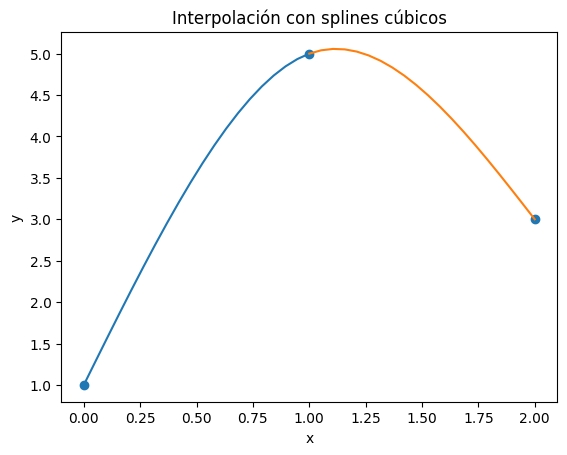

In [10]:
s = [
    {"a": 1, "b": 5.5, "c": 0, "d": -1.5},
    {"a": 5, "b": 1, "c": -4.5, "d": 1.5},
]


dibujar_spline(pts, s)

In [11]:
### ejercicio 2 
pts = [(0,-5),(1,-4),(2,3)]

def Spline(x, xi, *, a, b, c, d):
    return a + b * (x - xi) + c * (x - xi) ** 2 + d * (x - xi) ** 3

import matplotlib.pyplot as plt
import numpy as np


def dibujar_spline(pts, s):
    xs, ys = zip(*pts)
    for i, x_i in enumerate(xs[:-1]):
        _x = np.linspace(x_i, xs[i + 1], 20)
        _y = Spline(_x, x_i, **s[i])
        plt.plot(_x, _y)

    plt.scatter(xs, ys)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title("Interpolación con splines cúbicos")
    plt.show()

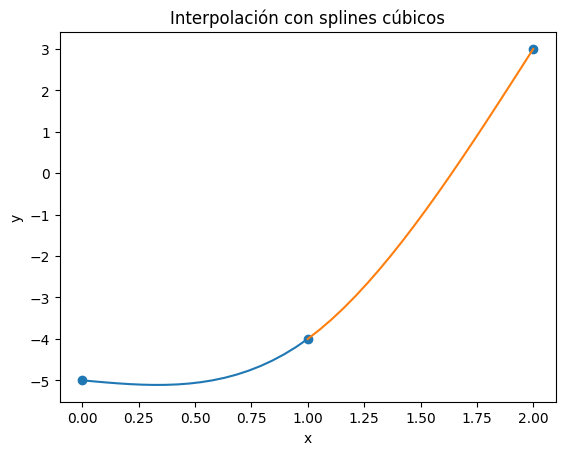

In [12]:
s = [
    {"a": -5, "b": -0.5, "c": 0, "d": 1.5},
    {"a": -4, "b": 4, "c": 4.5, "d": -1.5},
]


dibujar_spline(pts, s)

In [13]:
pts = [(0, -1), (1, 1), (2, 5) , (3,2)]

def Spline(x, xi, *, a, b, c, d):
    return a + b * (x - xi) + c * (x - xi) ** 2 + d * (x - xi) ** 3

import matplotlib.pyplot as plt
import numpy as np


def dibujar_spline(pts, s):
    xs, ys = zip(*pts)
    for i, x_i in enumerate(xs[:-1]):
        _x = np.linspace(x_i, xs[i + 1], 20)
        _y = Spline(_x, x_i, **s[i])
        plt.plot(_x, _y)

    plt.scatter(xs, ys)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title("Interpolación con splines cúbicos")
    plt.show()



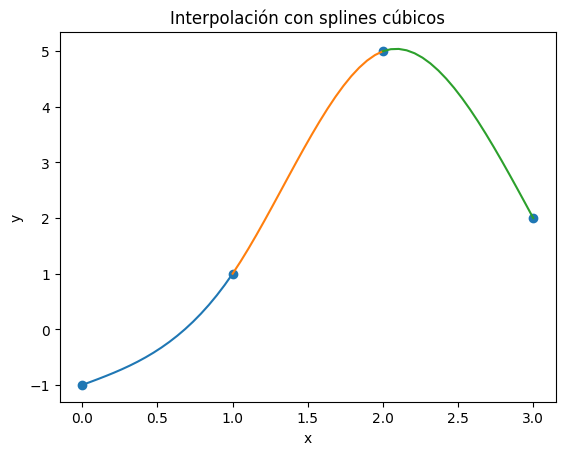

In [14]:
s = [
    {"a": -1, "b": 1, "c": 0, "d": 1},
    {"a": 1, "b": 4, "c": 3, "d": -3},
    {"a": 5, "b": 1, "c": -6, "d": 2}
]


dibujar_spline(pts, s)

# Parte 2
Completar código para definir la función Spline.

In [15]:
import sympy as sym
from IPython.display import display


# ###################################################################
def cubic_spline(xs: list[float], ys: list[float]) -> list[sym.Symbol]:
    """
    Cubic spline interpolation ``S``. Every two points are interpolated by a cubic polynomial
    ``S_j`` of the form ``S_j(x) = a_j + b_j(x - x_j) + c_j(x - x_j)^2 + d_j(x - x_j)^3.``

    xs must be different  but not necessarily ordered nor equally spaced.

    ## Parameters
    - xs, ys: points to be interpolated

    ## Return
    - List of symbolic expressions for the cubic spline interpolation.
    """

    points = sorted(zip(xs, ys), key=lambda x: x[0])

    xs = [x for x, _ in points]
    ys = [y for _, y in points]

    n = len(points) - 1

    h = [xs[i + 1] - xs[i] for i in range(n)]

    alpha = [0] * (n + 1)          # completar

    for i in range(1, n):
        alpha[i] = 3 / h[i] * (ys[i + 1] - ys[i]) - 3 / h[i - 1] * (ys[i] - ys[i - 1])

    l = [1]
    u = [0]
    z = [0]

    for i in range(1, n):
        l += [2 * (xs[i + 1] - xs[i - 1]) - h[i - 1] * u[i - 1]]
        u += [h[i] / l[i]]
        z += [(alpha[i] - h[i - 1] * z[i - 1]) / l[i]]      # completar

    l.append(1)
    z.append(0)
    c = [0] * (n + 1)

    x = sym.Symbol("x")
    splines = []

    for j in range(n - 1, -1, -1):
        c[j] = z[j] - u[j] * c[j + 1]
        b = (ys[j + 1] - ys[j]) / h[j] - h[j] * (c[j + 1] + 2 * c[j]) / 3
        d = (c[j + 1] - c[j]) / (3 * h[j])

        a = ys[j]                  # completar

        print(j, a, b, c[j], d)

        S = a + b*(x - xs[j]) + c[j]*(x - xs[j])**2 + d*(x - xs[j])**3   # completar

        splines.append(S)

    splines.reverse()

    return splines

In [16]:
xs = [0, 1, 2]
ys = [1, 5, 3]

splines = cubic_spline(xs=xs, ys=ys)
_ = [display(s) for s in splines]
print("______")
_ = [display(s.expand()) for s in splines]




1 5 1.0 -4.5 1.5
0 1 5.5 0.0 -1.5


-1.5*x**3 + 5.5*x + 1

1.0*x + 1.5*(x - 1)**3 - 4.5*(x - 1)**2 + 4.0

______


-1.5*x**3 + 5.5*x + 1

1.5*x**3 - 9.0*x**2 + 14.5*x - 2.0

In [17]:
### pts = [(0,-5),(1,-4),(2,3)]
xs =[0,1,2]
ys =[-5,-4,3] 
splines = cubic_spline (xs=xs , ys =ys)
_ =[display(s) for s in splines]
print("________ ")
_= [display(s.expand()) for s in splines] 

1 -4 4.0 4.5 -1.5
0 -5 -0.5 0.0 1.5


1.5*x**3 - 0.5*x - 5

4.0*x - 1.5*(x - 1)**3 + 4.5*(x - 1)**2 - 8.0

________ 


1.5*x**3 - 0.5*x - 5

-1.5*x**3 + 9.0*x**2 - 9.5*x - 2.0

In [18]:
### pts = [(0, -1), (1, 1), (2, 5) , (3,2)]
xs =[0,1,2,3]
ys =[-1,1,5,2] 
splines = cubic_spline (xs=xs , ys =ys)
_ =[display(s) for s in splines]
print("________ ")
_= [display(s.expand()) for s in splines] 

2 5 1.0 -6.0 2.0
1 1 4.0 3.0 -3.0
0 -1 1.0 0.0 1.0


1.0*x**3 + 1.0*x - 1

4.0*x - 3.0*(x - 1)**3 + 3.0*(x - 1)**2 - 3.0

1.0*x + 2.0*(x - 2)**3 - 6.0*(x - 2)**2 + 3.0

________ 


1.0*x**3 + 1.0*x - 1

-3.0*x**3 + 12.0*x**2 - 11.0*x + 3.0

2.0*x**3 - 18.0*x**2 + 49.0*x - 37.0


PUNTOS: [(0, 1), (1, 5), (2, 3)]

Ecuaciones:

S_0(x) =


-1.5*x**3 + 5.5*x + 1


S_1(x) =


1.5*x**3 - 9.0*x**2 + 14.5*x - 2.0

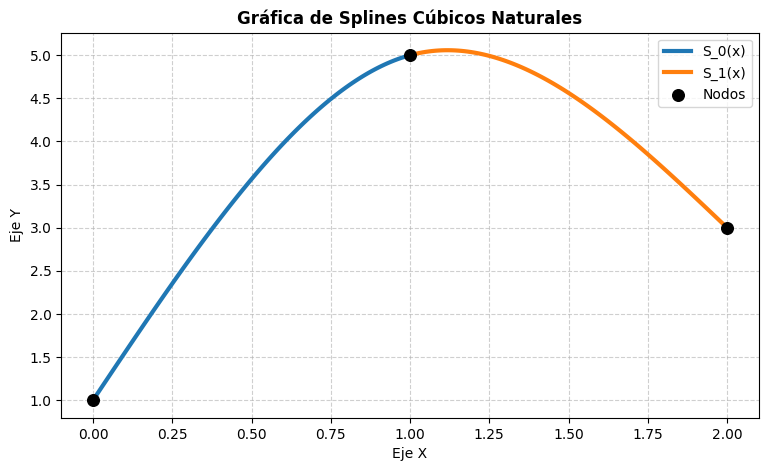


PUNTOS: [(0, -5), (1, -4), (2, 3)]

Ecuaciones:

S_0(x) =


1.5*x**3 - 0.5*x - 5


S_1(x) =


-1.5*x**3 + 9.0*x**2 - 9.5*x - 2.0

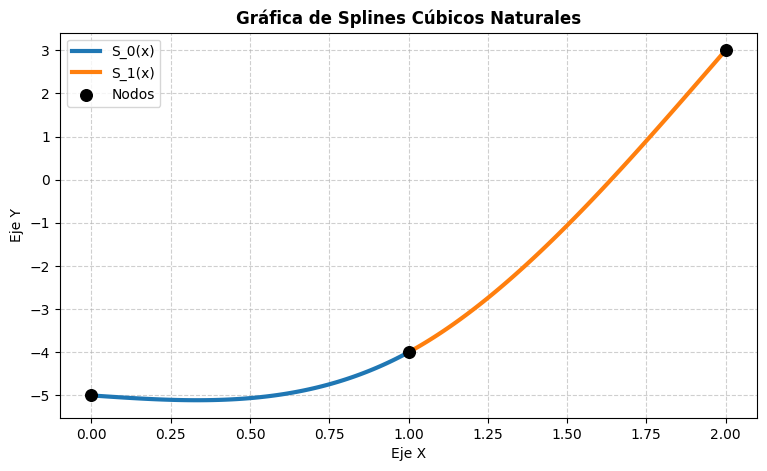


PUNTOS: [(0, -1), (1, 1), (2, 5), (3, 2)]

Ecuaciones:

S_0(x) =


1.0*x**3 + 1.0*x - 1


S_1(x) =


-3.0*x**3 + 12.0*x**2 - 11.0*x + 3.0


S_2(x) =


2.0*x**3 - 18.0*x**2 + 49.0*x - 37.0

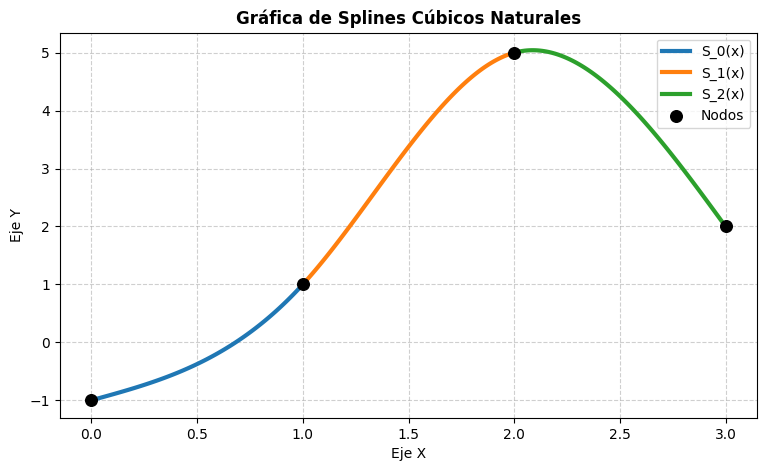

[1.0*x**3 + 1.0*x - 1,
 4.0*x - 3.0*(x - 1)**3 + 3.0*(x - 1)**2 - 3.0,
 1.0*x + 2.0*(x - 2)**3 - 6.0*(x - 2)**2 + 3.0]

In [22]:

import sympy as sym
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

def cubic_spline(xs: list[float], ys: list[float]):

    points = sorted(zip(xs, ys), key=lambda x: x[0])

    xs = [x for x, _ in points]
    ys = [y for _, y in points]

    n = len(points) - 1

    h = [xs[i + 1] - xs[i] for i in range(n)]

    alpha = [0] * (n + 1)

    for i in range(1, n):
        alpha[i] = (
            3 / h[i] * (ys[i + 1] - ys[i])
            - 3 / h[i - 1] * (ys[i] - ys[i - 1])
        )

    l = [1]
    u = [0]
    z = [0]

    for i in range(1, n):
        l.append(
            2 * (xs[i + 1] - xs[i - 1])
            - h[i - 1] * u[i - 1]
        )

        u.append(h[i] / l[i])

        z.append(
            (alpha[i] - h[i - 1] * z[i - 1])
            / l[i]
        )

    l.append(1)
    z.append(0)

    c = [0] * (n + 1)

    x = sym.Symbol("x")

    splines = []

    print(f"\nPUNTOS: {list(zip(xs, ys))}")
    print("\nEcuaciones:")

    for j in range(n - 1, -1, -1):

        c[j] = z[j] - u[j] * c[j + 1]

        b = (
            (ys[j + 1] - ys[j]) / h[j]
            - h[j] * (c[j + 1] + 2 * c[j]) / 3
        )

        d = (
            (c[j + 1] - c[j])
            / (3 * h[j])
        )

        a = ys[j]

        S = (
            a
            + b * (x - xs[j])
            + c[j] * (x - xs[j])**2
            + d * (x - xs[j])**3
        )

        splines.append({
            "expr": S,
            "a": a,
            "b": b,
            "c": c[j],
            "d": d,
            "xi": xs[j],
            "xf": xs[j + 1]
        })

    splines.reverse()

    # Mostrar ecuaciones expandidas
    for i, sp in enumerate(splines):
        print(f"\nS_{i}(x) =")
        display(sym.expand(sp["expr"]))

    # ==========================
    # GRÁFICA
    # ==========================

    plt.figure(figsize=(9, 5))

    for i, sp in enumerate(splines):

        x_vals = np.linspace(
            sp["xi"],
            sp["xf"],
            100
        )

        f = sym.lambdify(x, sp["expr"], "numpy")

        y_vals = f(x_vals)

        plt.plot(
            x_vals,
            y_vals,
            linewidth=3,
            label=f"S_{i}(x)"
        )

    plt.scatter(
        xs,
        ys,
        color="black",
        s=70,
        zorder=5,
        label="Nodos"
    )

    plt.title(
        "Gráfica de Splines Cúbicos Naturales",
        fontsize=12,
        fontweight="bold"
    )

    plt.xlabel("Eje X")
    plt.ylabel("Eje Y")

    plt.grid(True, linestyle="--", alpha=0.6)

    plt.legend()
    plt.show()

    return [sp["expr"] for sp in splines]


# ==========================
# PRUEBAS
# ==========================

cubic_spline([0, 1, 2], [1, 5, 3])

cubic_spline([0, 1, 2], [-5, -4, 3])

cubic_spline([0, 1, 2, 3], [-1, 1, 5, 2])
